# Norway Future Skills — Skill Demand Analysis

## Objective

This notebook examines **current skill demand in Norwegian job postings**.

It builds on the data-quality work from the previous notebook and focuses on four questions:

1. Which skills appear most often in job postings?
2. How many skills are associated with a typical job?
3. Is skill demand concentrated in a small number of common skills or spread across a long tail?
4. How does the skill-demand profile differ across major Norwegian cities?

## Analytical approach

The main unit of analysis is the **job–skill relationship**: one row represents one skill associated with one job posting.

Whenever demand is counted, unique `job_id` values are used so that a skill is not accidentally counted twice within the same posting.

> This notebook describes the **current sample**. It does not yet determine whether a skill is digital, AI-related, or important in the future; that classification is handled in the next notebook.


In [1]:
# Cell 02 — Load libraries and prepared datasets

import pandas as pd
import matplotlib.pyplot as plt

skills_df = pd.read_csv(
    "../data/processed/job_skills.csv"
)

jobs_df = pd.read_csv(
    "../data/processed/jobs_clean.csv"
)

print(
    f"Job-skill rows: {len(skills_df):,}"
)

print(
    f"Unique jobs in skill table: "
    f"{skills_df['job_id'].nunique():,}"
)

print(
    f"Jobs in cleaned dataset: "
    f"{jobs_df['job_id'].nunique():,}"
)

display(skills_df.head())


Job-skill rows: 95,324
Unique jobs in skill table: 10,000
Jobs in cleaned dataset: 10,000


,job_id,skills,skill
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Arkiv
1,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Brukerstøtte
2,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Digitalisering
3,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Dokumentasjonsforvaltning
4,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Informasjonsforvaltning


## 1. Validate the job–skill table

Before calculating demand, we confirm that the exploded skill table has the expected structure and check for duplicate job–skill pairs.

The expected columns are:

- `job_id` — unique identifier for the job posting
- `skills` — original comma-separated skill string
- `skill` — one extracted skill


In [2]:
# Cell 04 — Inspect structure and duplicate job-skill relationships

skills_df.info()

duplicate_job_skill_pairs = (
    skills_df[
        ["job_id", "skill"]
    ]
    .duplicated()
    .sum()
)

print(
    "\nDuplicated job-skill pairs:",
    duplicate_job_skill_pairs
)

print(
    "Unique observed skills:",
    f"{skills_df['skill'].nunique():,}"
)


<class 'pandas.DataFrame'>
RangeIndex: 95324 entries, 0 to 95323
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   job_id  95324 non-null  str  
 1   skills  95324 non-null  str  
 2   skill   95324 non-null  str  
dtypes: str(3)
memory usage: 2.2 MB

Duplicated job-skill pairs: 0
Unique observed skills: 10,997


## 2. Overall skill demand

Skill demand is measured as the number of **unique job postings** containing each skill.

This gives a direct answer to:

> Which skills are most frequently requested in the current sample?


In [3]:
# Cell 06 — Calculate skill frequency using unique job postings

skill_frequency = (
    skills_df
    .groupby("skill")
    .agg(
        job_count=("job_id", "nunique")
    )
    .reset_index()
    .sort_values(
        "job_count",
        ascending=False
    )
)

display(
    skill_frequency.head(20)
)


,skill,job_count
6217,Omsorg,1471
4801,Kundeservice,1396
3267,Helse,1106
1269,Butikk,1057
7597,Salg,981
5034,Leder,895
7841,Service,839
4533,Kontor,808
8699,Sykepleier,716
4144,Kasse,636


In [4]:
# Cell 07 — Describe the distribution of skill demand

display(
    skill_frequency["job_count"]
    .describe()
)


count    10997.000000
mean         8.668182
std         43.626013
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
max       1471.000000
Name: job_count, dtype: float64

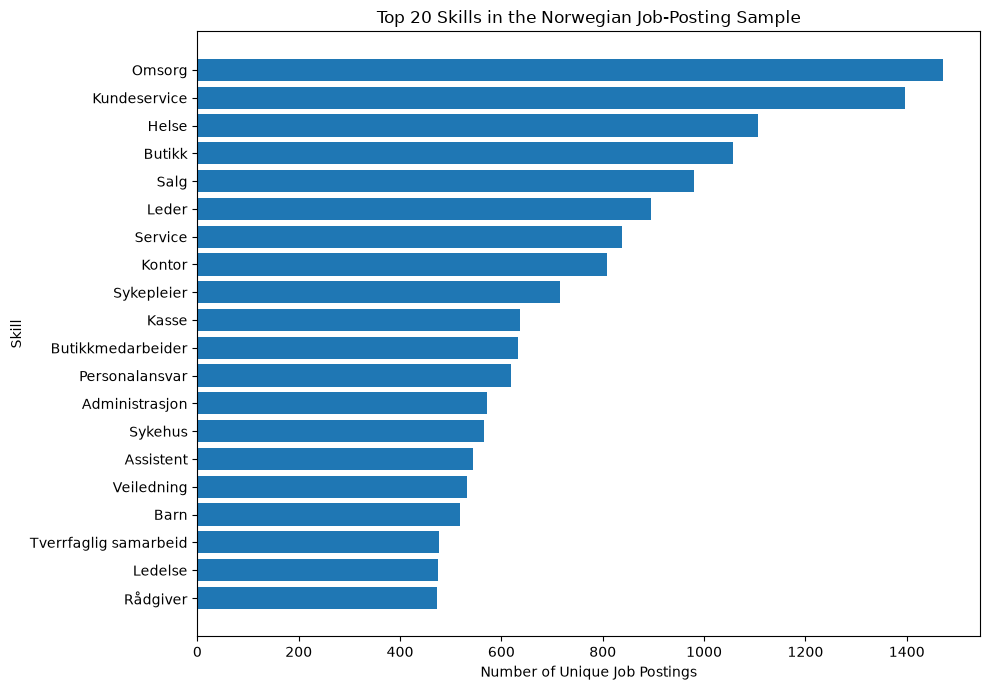

In [5]:
# Cell 08 — Visualize the 20 most demanded skills

top_skills = (
    skill_frequency
    .head(20)
    .sort_values(
        "job_count",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_skills["skill"],
    top_skills["job_count"]
)

plt.xlabel("Number of Unique Job Postings")
plt.ylabel("Skill")
plt.title("Top 20 Skills in the Norwegian Job-Posting Sample")
plt.tight_layout()
plt.show()


### Interpretation — overall demand

The most frequently observed skills are dominated by broad workplace and sector-specific capabilities such as:

- care and health (`Omsorg`, `Helse`, `Sykepleier`)
- customer service and retail (`Kundeservice`, `Butikk`, `Salg`)
- office and administration (`Kontor`, `Administrasjon`)
- leadership and responsibility (`Leder`, `Personalansvar`, `Ledelse`)

This provides a useful **current-demand baseline**.

However, frequency alone does not tell us whether a skill is technologically advanced, AI-related, or likely to become more important in the future. Those questions require a separate classification framework.


## 3. Number of skills per job posting

The source data usually attaches several skill tags to each job.

Examining the number of skills per job helps us understand whether the exploded table is structurally consistent and whether a small number of postings have unusually few or many observed skills.


In [6]:
# Cell 11 — Count unique skills associated with each job

job_skill_count = (
    skills_df
    .groupby("job_id")
    .agg(
        number_of_skills=("skill", "nunique")
    )
    .reset_index()
)

print(
    "Jobs represented:",
    f"{len(job_skill_count):,}"
)

display(
    job_skill_count.head()
)


Jobs represented: 10,000


,job_id,number_of_skills
0,0008dd66-d1c7-41ae-a911-1d6d0b84e092,10
1,001773d0-923c-4001-bea7-bb53098f5ba6,8
2,001903b6-c738-42b0-b70c-a9d13d1cbc85,10
3,001e12b0-b264-4fc6-9bb7-c9b42ff6dcf4,6
4,0028b108-259b-4554-8439-55bdc19f374e,10


In [7]:
# Cell 12 — Summarize skills per job

display(
    job_skill_count[
        "number_of_skills"
    ].describe()
)


count    10000.000000
mean         9.532400
std          0.806979
min          1.000000
25%          9.000000
50%         10.000000
75%         10.000000
max         13.000000
Name: number_of_skills, dtype: float64

In [8]:
# Cell 13 — Inspect jobs with unusually few skills

display(
    job_skill_count
    .sort_values(
        "number_of_skills"
    )
    .head(20)
)


,job_id,number_of_skills
1603,2961d69c-1023-44f7-8ead-103517f78ec7,1
6412,a33cf922-6b21-4ec8-b7e9-8a681678cfb3,1
6976,b114e7c5-659e-4f0f-8d86-249ee35a7882,1
8635,dd5c41ec-7d7b-402a-8c9e-6ab0a8a49f5c,1
8452,d88def75-e316-4a56-891a-8efa867feb24,1
5925,9759085b-d0a0-4896-b519-50df4d3aee97,1
8562,db647d74-6ec7-42d0-a9aa-7562f9648fcc,1
8257,d35cd6df-dd47-4dce-8f4c-8efcc362879a,1
4537,746bb7e7-290d-4fb3-957d-8a2df09c5578,1
8988,e60ccf80-7b0d-420e-adfd-f04cbabe91c4,1


In [9]:
# Cell 14 — Build the skills-per-job distribution

skill_count_distribution = (
    job_skill_count[
        "number_of_skills"
    ]
    .value_counts()
    .sort_index()
)

display(
    skill_count_distribution
)


number_of_skills
1       14
4        1
5       11
6       14
7       76
8     1054
9     2110
10    6709
11      10
13       1
Name: count, dtype: int64

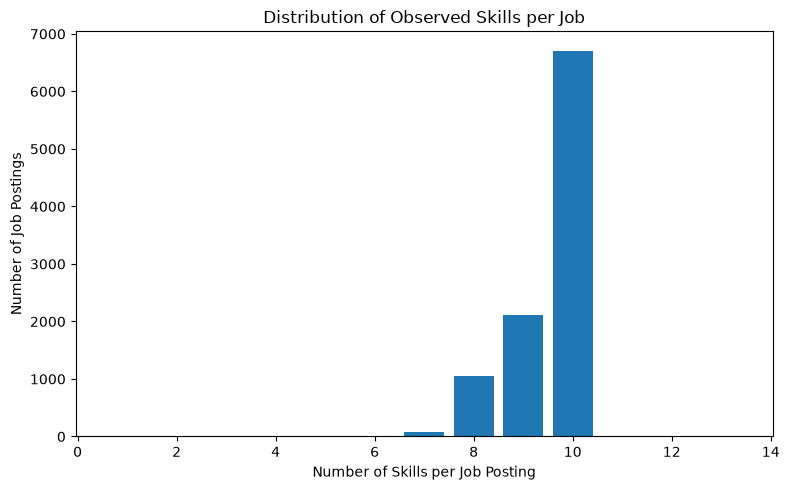

In [10]:
# Cell 15 — Visualize the number of skills per job

plt.figure(figsize=(8, 5))

plt.bar(
    skill_count_distribution.index,
    skill_count_distribution.values
)

plt.xlabel("Number of Skills per Job Posting")
plt.ylabel("Number of Job Postings")
plt.title("Distribution of Observed Skills per Job")
plt.tight_layout()
plt.show()


### Interpretation — skills per job

The job postings are highly consistent in the number of observed skill tags:

- the average is about **9.5 skills per job**
- the median is **10**
- **6,709 of 10,000 postings** contain exactly 10 observed skills
- most postings contain between **8 and 10** skills
- only a very small number contain unusually few skills

This pattern likely reflects the structure of the source tagging system as much as employer behavior. Therefore, the number of observed skills should not be interpreted as the complete set of capabilities genuinely required for a role.


## 4. Skill diversity and the long tail

The next question is whether the labor market is dominated by a small vocabulary of common skills or contains many specialized terms.

A long-tailed distribution would mean:

- a small number of skills appear very frequently
- many skills occur only once or a few times


In [11]:
# Cell 18 — Summarize skill-frequency diversity

print(
    "Unique skills:",
    f"{skill_frequency['skill'].nunique():,}"
)

print(
    "Skills appearing in exactly one job:",
    f"{(skill_frequency['job_count'] == 1).sum():,}"
)

print(
    "Skills appearing in four or fewer jobs:",
    f"{(skill_frequency['job_count'] <= 4).sum():,}"
)

display(
    skill_frequency["job_count"]
    .describe()
)


Unique skills: 10,997
Skills appearing in exactly one job: 5,720
Skills appearing in four or fewer jobs: 8,574


count    10997.000000
mean         8.668182
std         43.626013
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
max       1471.000000
Name: job_count, dtype: float64

In [12]:
# Cell 19 — Inspect the most common 50 skills

display(
    skill_frequency.head(50)
)


,skill,job_count
6217,Omsorg,1471
4801,Kundeservice,1396
3267,Helse,1106
1269,Butikk,1057
7597,Salg,981
5034,Leder,895
7841,Service,839
4533,Kontor,808
8699,Sykepleier,716
4144,Kasse,636


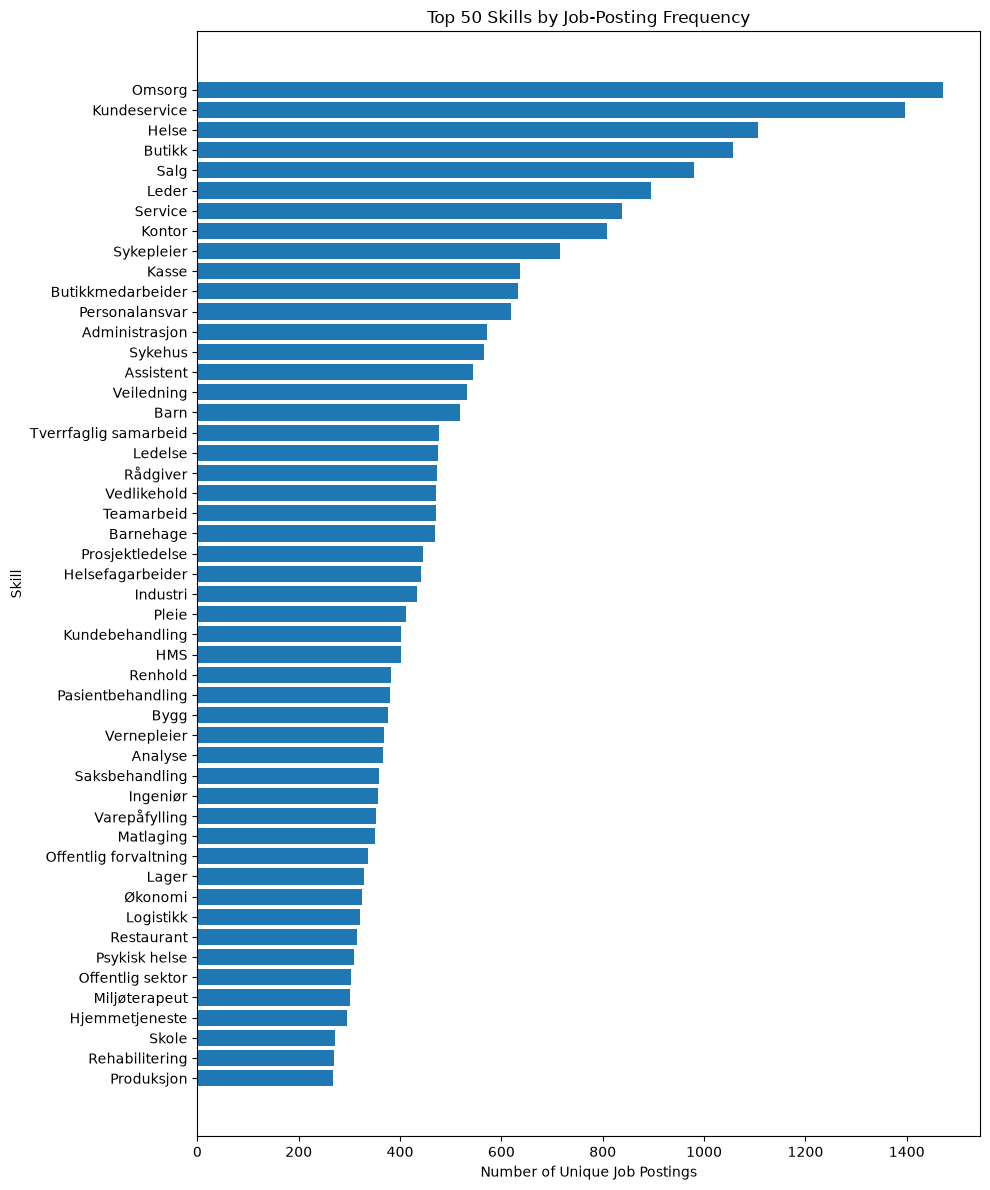

In [13]:
# Cell 20 — Visualize the top 50 skills

top_50_skills = (
    skill_frequency
    .head(50)
    .sort_values(
        "job_count",
        ascending=True
    )
)

plt.figure(figsize=(10, 12))

plt.barh(
    top_50_skills["skill"],
    top_50_skills["job_count"]
)

plt.xlabel("Number of Unique Job Postings")
plt.ylabel("Skill")
plt.title("Top 50 Skills by Job-Posting Frequency")
plt.tight_layout()
plt.show()


### Interpretation — skill concentration and diversity

The skill vocabulary is highly fragmented:

- there are **10,997 unique observed skill labels**
- the median skill appears in only **one** job
- 75% of skills appear in **four or fewer** jobs
- a relatively small group of broad skills appears hundreds or more than one thousand times

This creates a classic **long-tail distribution**.

For later AI and digital-skill analysis, this matters because rare terms can contain useful specialized technologies, but they can also contain spelling variants, highly specific concepts, and noise. Later classification should therefore avoid treating every rare label as equally reliable.


## 5. Connect skills back to job context

Skill frequency becomes more useful when connected to job metadata.

We merge the long-format skill table with:

- `city`
- `category`
- `occupation`
- `title`

This makes it possible to investigate geographic and job-context differences.

> The occupation field was found to have poor coverage and malformed values in the data-quality notebook, so it is retained for reference but is **not used as a primary analytical variable**.


In [14]:
# Cell 23 — Merge skill records with job metadata

skills_jobs_df = (
    skills_df
    .merge(
        jobs_df[
            [
                "job_id",
                "city",
                "category",
                "occupation",
                "title"
            ]
        ],
        on="job_id",
        how="left"
    )
)

print(
    f"Merged job-skill rows: "
    f"{len(skills_jobs_df):,}"
)

display(
    skills_jobs_df.head()
)


Merged job-skill rows: 95,324


,job_id,skills,skill,city,category,occupation,title
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Arkiv,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
1,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Brukerstøtte,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
2,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Digitalisering,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
3,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Dokumentasjonsforvaltning,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
4,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Informasjonsforvaltning,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...


In [15]:
# Cell 24 — Inspect category and city context

print("Most common category values:")
display(
    skills_jobs_df[
        "category"
    ]
    .value_counts()
    .head(15)
)

print("\nLargest cities by unique job postings:")
display(
    jobs_df.loc[
        jobs_df["city"].ne(
            "Missing location"
        ),
        "city"
    ]
    .value_counts()
    .head(15)
)


Most common category values:


category
Sykepleier, Sykepleier, Sykepleiere                                                            2219
Butikkmedarbeider, Butikkmedarbeider, Butikkmedarbeidere                                       1991
Helsefagarbeider, Helsefagarbeider, Helsefagarbeidere                                          1580
Brukerstyrt personlig assistent (BPA), Brukerstyrt personlig assistent (BPA), Hjemmehjelper    1434
Butikkmedarbeider dagligvarebutikk, Butikkmedarbeider dagligvarebutikk, Butikkmedarbeidere      804
Sykepleier, Sykepleiere, Vernepleiere, Vernepleier, personlig assistent                         703
Butikkmedarbeidere, Butikkmedarbeider, butikkmedarbeider                                        691
Miljøterapeut, Miljøterapeut, Miljøarbeidere innen sosiale fagfelt                              686
Prosjektleder, Prosjektleder, Andre administrative ledere                                       607
Avdelingsleder, Avdelingsleder, Andre ledere av produksjon og tjenesteyting                


Largest cities by unique job postings:


city
OSLO              1855
TRONDHEIM          417
BERGEN             411
STAVANGER          285
BODØ               215
TROMSØ             200
KONGSBERG          141
SANDNES            141
ÅLESUND            138
KRISTIANSAND S     128
DRAMMEN            119
HAUGESUND          101
LØRENSKOG           87
SKIEN               81
TØNSBERG            81
Name: count, dtype: int64

### Context-field limitations

The source `category` field contains long compound labels and repeated occupational descriptions rather than a clean single category. It is therefore useful for context, but not ideal as the main grouping variable.

The `occupation` field is even less reliable because of missing and malformed extraction.

For this notebook, **city** provides the cleanest contextual dimension, so the remaining analysis focuses on geographic differences in skill demand.


## 6. Skill demand by city

To compare skill profiles across cities, we calculate two related measures:

- `job_count` — number of unique jobs in the city containing a skill
- `skill_share` — the skill's share of all observed job–skill relationships in that city

`skill_share` is useful for comparing cities of different sizes, but it should **not** be read as the percentage of jobs requiring the skill.

We also calculate `job_share`, which is the percentage of jobs in the city containing the skill.


In [16]:
# Cell 27 — Calculate city-level skill demand

city_skill_frequency = (
    skills_jobs_df[
        skills_jobs_df["city"].ne(
            "Missing location"
        )
    ]
    .groupby(
        ["city", "skill"]
    )
    .agg(
        job_count=("job_id", "nunique")
    )
    .reset_index()
)

display(
    city_skill_frequency.head()
)


,city,skill,job_count
0,AKLAND,Anleggsleder,1
1,AKLAND,Arbeidsmiljø,1
2,AKLAND,Betongarbeider,1
3,AKLAND,Bygg,1
4,AKLAND,Byggeplass,1


In [17]:
# Cell 28 — Add city-level normalization measures

city_total_skill_mentions = (
    city_skill_frequency
    .groupby("city")
    .agg(
        city_total_skill_mentions=(
            "job_count",
            "sum"
        )
    )
    .reset_index()
)

city_total_jobs = (
    jobs_df[
        jobs_df["city"].ne(
            "Missing location"
        )
    ]
    .groupby("city")
    .agg(
        city_total_jobs=(
            "job_id",
            "nunique"
        )
    )
    .reset_index()
)

city_skill_share = (
    city_skill_frequency
    .merge(
        city_total_skill_mentions,
        on="city",
        how="left"
    )
    .merge(
        city_total_jobs,
        on="city",
        how="left"
    )
)

city_skill_share[
    "skill_share"
] = (
    city_skill_share["job_count"]
    /
    city_skill_share[
        "city_total_skill_mentions"
    ]
)

city_skill_share[
    "job_share"
] = (
    city_skill_share["job_count"]
    /
    city_skill_share[
        "city_total_jobs"
    ]
)

display(
    city_skill_share.head()
)


,city,skill,job_count,city_total_skill_mentions,city_total_jobs,skill_share,job_share
0,AKLAND,Anleggsleder,1,19,2,0.052632,0.5
1,AKLAND,Arbeidsmiljø,1,19,2,0.052632,0.5
2,AKLAND,Betongarbeider,1,19,2,0.052632,0.5
3,AKLAND,Bygg,1,19,2,0.052632,0.5
4,AKLAND,Byggeplass,1,19,2,0.052632,0.5


## 7. Compare major city skill profiles

Rather than manually selecting cities, we identify the **four largest named city markets** in the cleaned job sample.

This produces the major-city comparison used below.


In [18]:
# Cell 30 — Identify the four largest named city markets

top_cities = (
    jobs_df.loc[
        jobs_df["city"].ne(
            "Missing location"
        ),
        "city"
    ]
    .value_counts()
    .head(4)
    .index
    .tolist()
)

print(
    "Cities compared:",
    top_cities
)


Cities compared: ['OSLO', 'TRONDHEIM', 'BERGEN', 'STAVANGER']


In [19]:
# Cell 31 — Select the top 10 normalized skills in each major city

city_comparison = (
    city_skill_share[
        city_skill_share[
            "city"
        ].isin(top_cities)
    ]
    .sort_values(
        [
            "city",
            "skill_share"
        ],
        ascending=[
            True,
            False
        ]
    )
)

top_city_skills = (
    city_comparison
    .groupby(
        "city",
        group_keys=False
    )
    .head(10)
)

display(
    top_city_skills[
        [
            "city",
            "skill",
            "job_count",
            "skill_share",
            "job_share"
        ]
    ]
)


,city,skill,job_count,skill_share,job_share
3142,BERGEN,Kontor,43,0.010911,0.104623
3188,BERGEN,Kundeservice,43,0.010911,0.104623
3650,BERGEN,Salg,39,0.009896,0.094891
3219,BERGEN,Leder,34,0.008627,0.082725
3631,BERGEN,Rådgiver,33,0.008374,0.080292
3383,BERGEN,Omsorg,32,0.008120,0.077859
3537,BERGEN,Prosjektledelse,32,0.008120,0.077859
2471,BERGEN,Administrasjon,31,0.007866,0.075426
2957,BERGEN,Helse,30,0.007612,0.072993
2654,BERGEN,Bygg,27,0.006851,0.065693


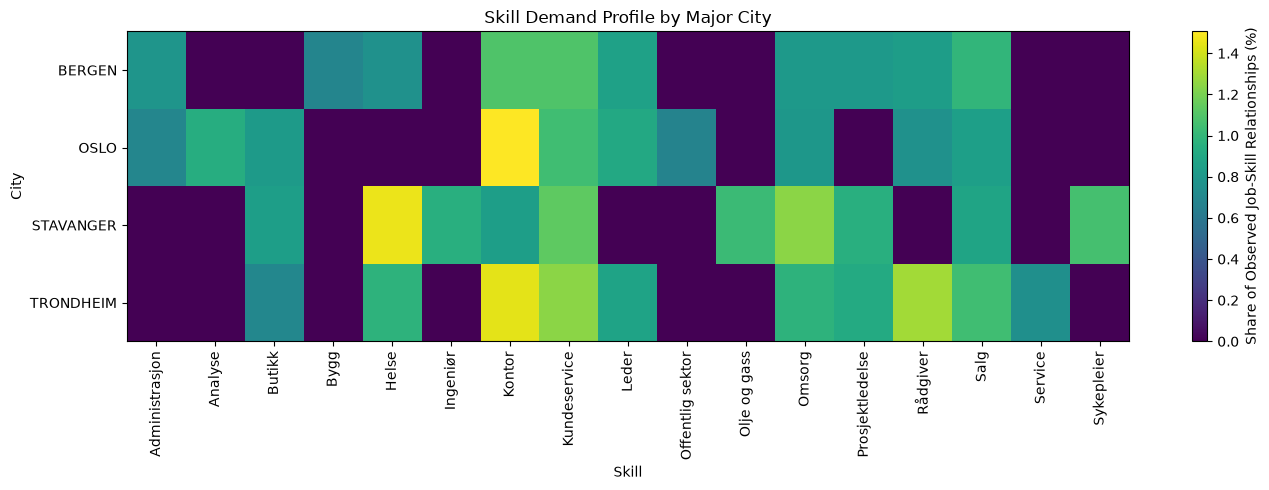

In [20]:
# Cell 32 — Create a heatmap of major-city skill profiles

city_heatmap = (
    top_city_skills
    .pivot(
        index="city",
        columns="skill",
        values="skill_share"
    )
    .fillna(0)
    * 100
)

plt.figure(figsize=(14, 5))

image = plt.imshow(
    city_heatmap,
    aspect="auto"
)

plt.xticks(
    range(
        len(
            city_heatmap.columns
        )
    ),
    city_heatmap.columns,
    rotation=90
)

plt.yticks(
    range(
        len(
            city_heatmap.index
        )
    ),
    city_heatmap.index
)

plt.title(
    "Skill Demand Profile by Major City"
)

plt.xlabel("Skill")
plt.ylabel("City")

colorbar = plt.colorbar(image)
colorbar.set_label(
    "Share of Observed Job-Skill Relationships (%)"
)

plt.tight_layout()
plt.show()


### Interpretation — regional skill profiles

The major cities share several broad labor-market needs, including customer service, sales, office work, leadership, care, and project-related skills.

At the same time, the normalized profiles reveal meaningful regional differences:

- **Oslo** shows stronger visibility of office, analysis, advisory, administration, public-sector, and project-related skills.
- **Stavanger** shows a clearer energy and engineering profile, including health demand alongside `Olje og gass`, engineering, and project skills.
- **Trondheim** has a mix of office, advisory, health, service, and project-oriented demand.
- **Bergen** has a relatively balanced profile spanning office, customer service, sales, care, health, administration, and construction.

These are descriptive patterns in the collected sample. They should not be interpreted as complete measures of each city's economy.


## 8. Save analysis outputs

The prepared outputs are saved for the AI/future-skills notebook and later dashboard work.

Saved files:

- `skills_jobs_analysis.csv` — job–skill relationships enriched with job metadata
- `skill_frequency.csv` — overall demand for each observed skill
- `city_skill_analysis.csv` — city-level skill counts and normalized demand measures


In [21]:
# Cell 35 — Save processed analysis tables

skills_jobs_df.to_csv(
    "../data/processed/skills_jobs_analysis.csv",
    index=False
)

skill_frequency.to_csv(
    "../data/processed/skill_frequency.csv",
    index=False
)

city_skill_share.to_csv(
    "../data/processed/city_skill_analysis.csv",
    index=False
)

print("Analysis outputs saved.")


Analysis outputs saved.


In [22]:
# Cell 36 — Verify saved files

from pathlib import Path

output_files = [
    Path(
        "../data/processed/"
        "skills_jobs_analysis.csv"
    ),
    Path(
        "../data/processed/"
        "skill_frequency.csv"
    ),
    Path(
        "../data/processed/"
        "city_skill_analysis.csv"
    )
]

for file_path in output_files:
    print(
        file_path,
        file_path.exists()
    )


..\data\processed\skills_jobs_analysis.csv True
..\data\processed\skill_frequency.csv True
..\data\processed\city_skill_analysis.csv True


# Summary

This notebook established the current skill-demand baseline for the Norwegian job-posting sample.

## Main findings

- The dataset contains **10,997 unique observed skill labels**, showing a highly diverse skill vocabulary.
- Demand is strongly long-tailed: many skills appear only once or a few times, while a small number of broad skills appear in hundreds or more than one thousand postings.
- Current high-frequency demand is concentrated around healthcare, care, customer service, retail, administration, leadership, and service-related skills.
- Most postings contain approximately **9–10 observed skill tags**, which likely reflects the source tagging structure.
- Regional profiles differ after normalizing for city size. Oslo has a stronger knowledge-work and administrative profile, while Stavanger shows clearer energy and engineering signals; Bergen and Trondheim have broader mixed profiles.
- The source occupation field is not reliable enough to support occupation-based conclusions, and the category field is too fragmented to act as the main grouping variable.

## Next step

The next notebook moves beyond raw frequency and asks which observed skills are specifically **digital, AI-related, and relevant to future-oriented labor-market demand** using an external ESCO-based validation framework.
